# Exploratory data analysis

P.S. Для простоты работы и анализа, ноутбук был разбит на несколько

Датасет представляет собой записи о погодных и временных условия, которые могут теоритически коррелировать с кол-вом велосипедов, которые берутся в аренду

## Постановка задачи

### Бизнес-контекст
Capital Bikeshare - сервис велопроката в Вашингтоне (США). Оператор хочет точно прогнозировать почасовой спрос на велосипеды, чтобы:
- оптимально перераспределять велосипеды между станциями до пиковых часов
- планировать техническое обслуживание в периоды низкого спроса
- снизить потери от пустых или переполненных станций


### Почему ML
Спрос нелинейно зависит от времени суток, погоды, сезона и типа дня. Простые правила не захватывают взаимодействия (например, утренний час-пик в ясную погоду vs туман в понедельник). ML позволяет автоматически извлечь эти паттерны из исторических данных.


### Тип задачи
**Регрессия**: целевая переменная `cnt` - непрерывная (целочисленная) переменная, количество арендованных велосипедов за час.


### Целевые метрики качества
| Метрика | Обоснование |
|---------|-------------|
| **RMSE** | Основная метрика; сильнее штрафует за крупные ошибки, что важно для пиковых часов |
| **MAE** | Легко интерпретируется операционной командой (ошибка в единицах велосипедов) |
| **R²** | Доля объяснённой дисперсии; удобен для сравнения моделей |


### Источник данных
UCI Machine Learning Repository - Bike Sharing Dataset (Hadi Fanaee-T, 2013). 17 379 почасовых наблюдений за 2011–2012 гг. по данным Capital Bikeshare.


### Ограничения и допущения
- Данные охватывают только два года (2011–2012); модель не экстраполируется на будущий рост системы
- Данные по одному городу (Вашингтон, DC) - обобщаемость на другие города ограничена
- Внешние события (аварии, массовые мероприятия, поломки станций) в датасете не отражены

## Импорты

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

## Загрузка датасета

In [42]:
raw_bikes = pd.read_csv("./datasets/raw.csv")

raw_bikes.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


В датасете 14 полей, описание каждого

- `dteday` - Дата
- `season` - 1:Зима, 2:Весна, 3:Лето, 4:Осень
- `yr` - Год (0: 2011, 1: 2012)
- `mnth` - месяц (1 to 12)
- `hr` - час (0 to 23)
- `holiday` - Является ли день праздничным (0:Обычный, 1:Праздничный)
- `weekday` - день недели
- `workingday` - Является ли день выходным или праздничным (1:Обычный день, 0:Праздничный или выходной)
- `weathersit` - 1:Ясная или облачная погода 2:Туманно и облачно 3:Легкий снег или дождь 4:Слег с туманом или сильный град/дождь (В описании датасета на в файле ошибка)
- `temp` - Нормализованная температура в цельсиях
- `atemp` - Нормализованная "ощущаемая" температура в цельсиях
- `hum` - Нормализованная влажность
- `windspeed` - Нормализованная скорость векра
- `cnt` - целевая переменная: общее кол-ов арендаторов

In [43]:
raw_bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


Как видно, в датасете отсутствуют пропуски

## Приведение типов

Типы в csv в целом изменений не требуют, за исключением даты

In [44]:
raw_bikes["dteday"] = pd.to_datetime( raw_bikes["dteday"])

## Анализ одной переменной

### Целевая переменная

Проанализирую распределение целевой переменной cnt

<Axes: ylabel='Count'>

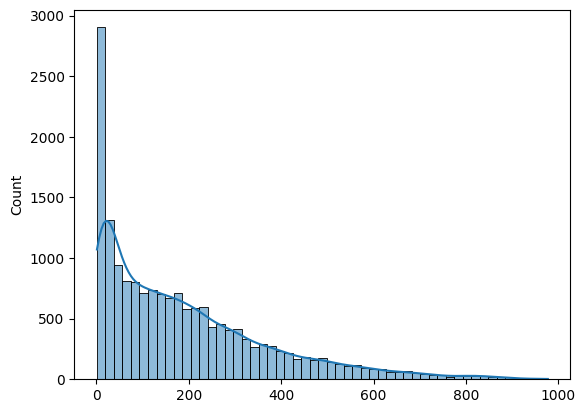

In [45]:
sns.histplot(data=list(raw_bikes["cnt"]), kde=True)

По графику понятно, что чаще всего кол-во ареднованных велосипедов оказывает около нуля. Длинный хвост справа

<Axes: ylabel='Count'>

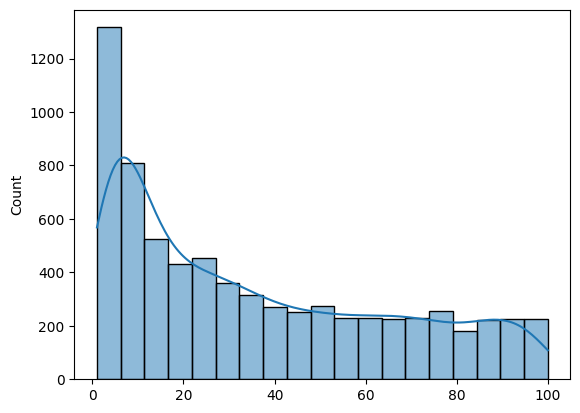

In [46]:
sns.histplot(data=list(raw_bikes[raw_bikes["cnt"] <= 100]["cnt"]), kde=True)

In [47]:
for i in range(0, 10):
    print(f"Кол-во значений {i}: {len(raw_bikes[raw_bikes["cnt"] == i])}")

Кол-во значений 0: 0
Кол-во значений 1: 158
Кол-во значений 2: 208
Кол-во значений 3: 224
Кол-во значений 4: 231
Кол-во значений 5: 260
Кол-во значений 6: 236
Кол-во значений 7: 198
Кол-во значений 8: 182
Кол-во значений 9: 128


На промежутке от 0 до 100 видно, что достотаточно часто кол-во велосипедов в аренде около нуля, однако значений 0 нет, мода от 0 до 9 = 5

### Погодные значения

Проведу анализ распределений погодных значений

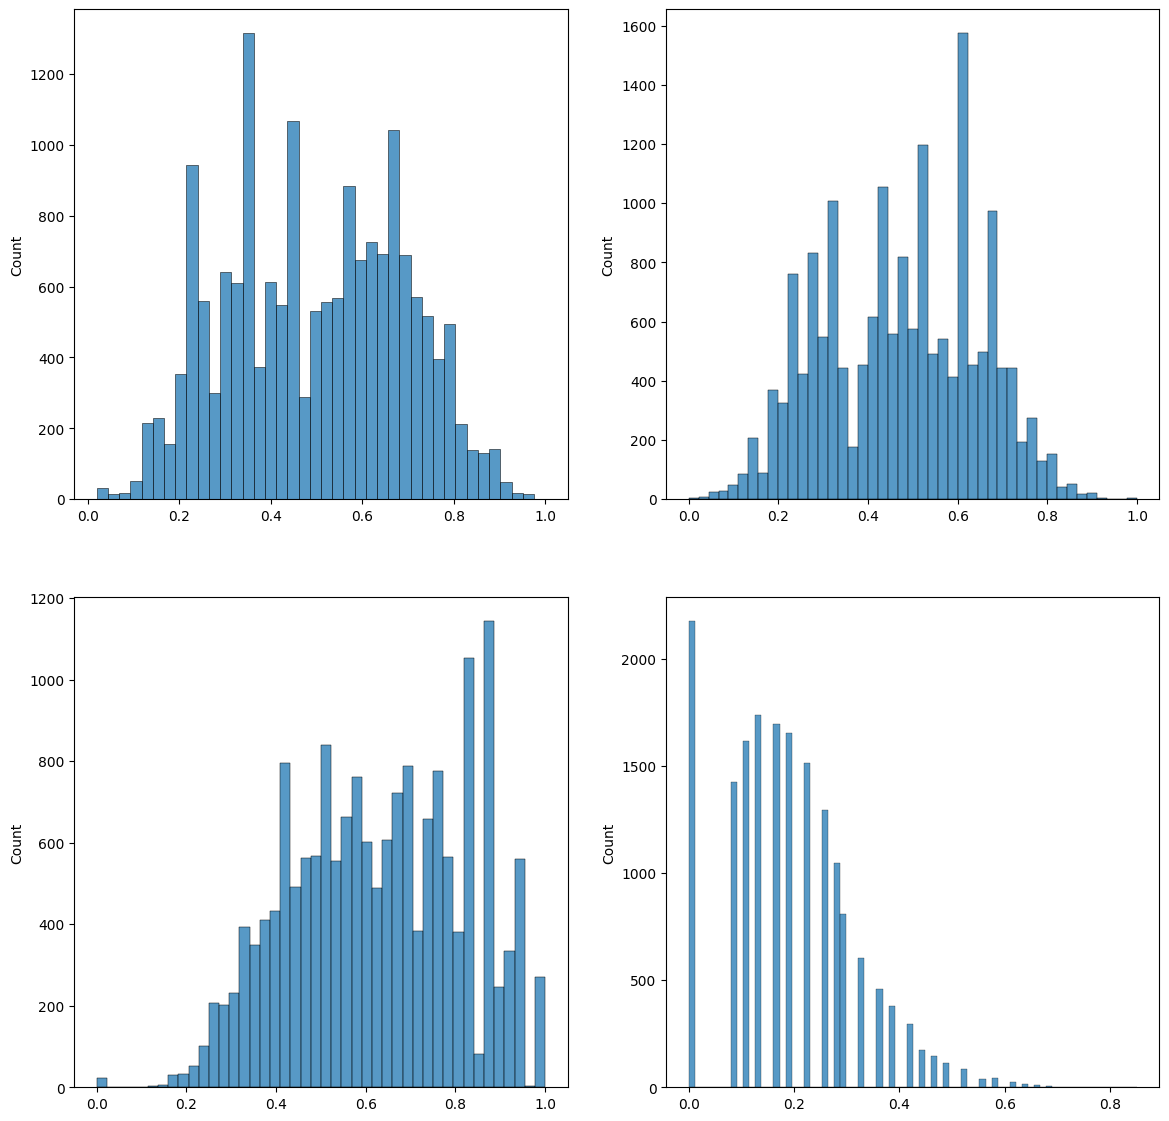

In [48]:
fig, ax = plt.subplots(2, 2)

cols = ["temp", "atemp", "hum", "windspeed"]

for i, axis in enumerate(ax.flatten()):
    sns.histplot(data=list(raw_bikes[cols[i]]), ax=axis)

fig.set_size_inches(14, 14)

По гистограммам понятно, что данные распределены бимодально, влажность и скорость ветра немного смещены

## Анализ по многим переменным

### Анализ количества аренды к времени

In [49]:
def quantile(x: pd.Series, workday: int, q: float) -> float:
    return x[raw_bikes.loc[x.index, "workingday"] == workday].quantile(q)

bikes_cnt_by_hr = raw_bikes.groupby("hr").agg(
    total_median=("cnt", "mean"),
    weekends_median=("cnt", lambda x: quantile(x, 0, 0.5)),
    weekends_q25=("cnt", lambda x: quantile(x, 0, 0.25)),
    weekends_q75=("cnt", lambda x: quantile(x, 0, 0.75)),

    workday_median=("cnt", lambda x: quantile(x, 1, 0.5)),
    workday_q25=("cnt", lambda x: quantile(x, 1, 0.25)),
    workday_q75=("cnt", lambda x: quantile(x, 1, 0.75)),
)

bikes_cnt_by_hr.head()

,total_median,weekends_median,weekends_q25,weekends_q75,workday_median,workday_q25,workday_q75
hr,,,,,,,
0,53.898072,93.5,46.25,122.75,33.0,21.0,48.0
1,33.375691,71.0,37.50,94.75,14.0,9.0,22.0
2,22.869930,54.0,29.75,72.25,7.0,4.0,12.0
3,11.727403,25.0,14.50,34.50,4.0,3.0,6.0
4,6.352941,7.0,4.00,12.00,5.0,3.0,7.0


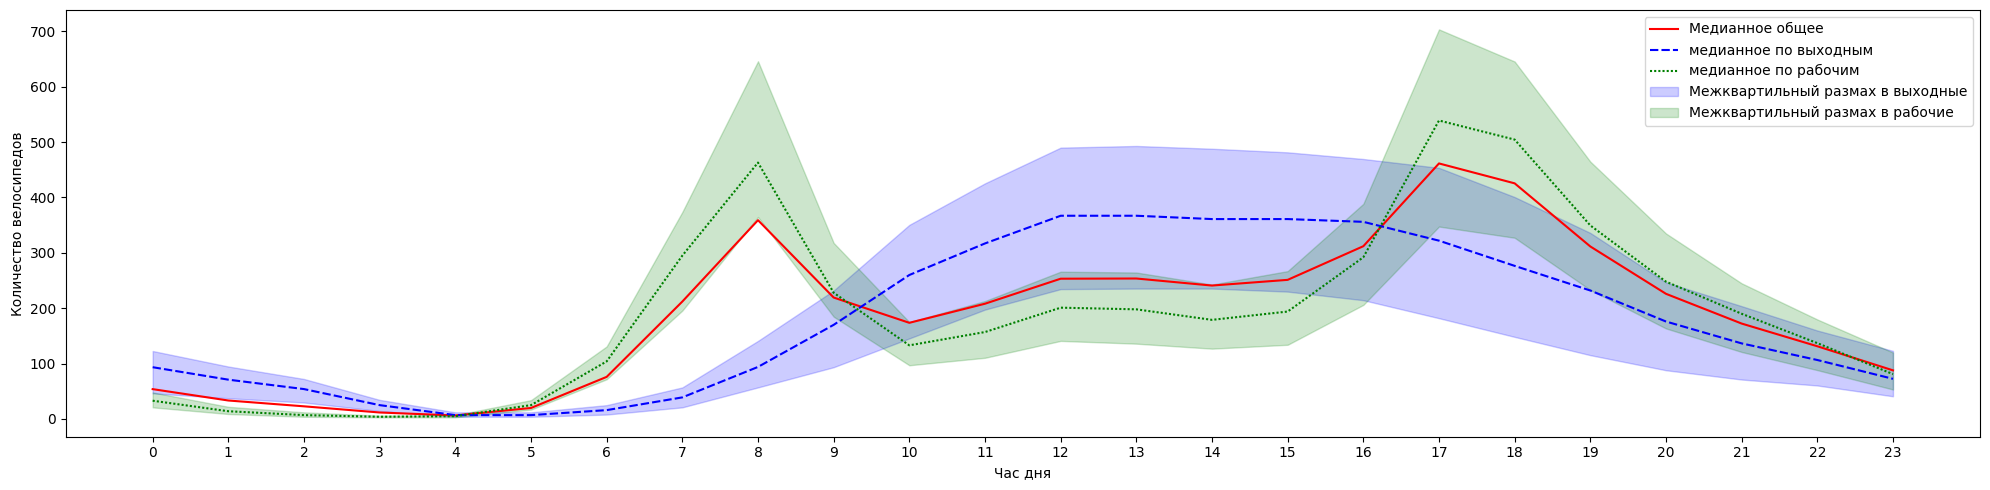

In [50]:
f, ax = plt.subplots(figsize=(20, 5))

bikes_plot = bikes_cnt_by_hr[
    ["total_median", "weekends_median", "workday_median"]
].copy()
bikes_plot.columns = [
    "Медианное общее",
    "медианное по выходным",
    "медианное по рабочим",
]

sns.lineplot(
    data=bikes_plot,
    ax=ax,
    palette=["red", "blue", "green"],
)

plt.fill_between(
    bikes_cnt_by_hr.index,
    bikes_cnt_by_hr["weekends_q25"],
    bikes_cnt_by_hr["weekends_q75"],
    alpha=0.2,
    color="blue",
    label="Межквартильный размах в выходные",
)

plt.fill_between(
    bikes_cnt_by_hr.index,
    bikes_cnt_by_hr["workday_q25"],
    bikes_cnt_by_hr["workday_q75"],
    alpha=0.2,
    color="green",
    label="Межквартильный размах в рабочие",
)

plt.xticks(range(0, 24))

plt.xlabel("Час дня")
plt.ylabel("Количество велосипедов")
plt.legend()
plt.tight_layout()
plt.show()

По графику видно, что:
- Для выходных и праздников самое популярное время аренды находится около обеденного времени (с 12 по 16). Это вероятно время прогулок, когда люди берут велосипеды для развлечения или спорта
- Для рабочих дней самое частое время это между 7 и 9 утра, а тажке около 17-18 часов. Тем самым можно предположить что люди арендуют велосипеды для поездки на работу и с работы

Также по общему среднему можно сделать вывод, что паттерн аренды в рабочее время перевешивает поведение людей в выходные, поэтому средее почти идеально попадает в межквартильный размах рабочего времени

### Рост целевой переменной со временем

/tmp/ipykernel_55584/623770783.py:8: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  bikes_by_days = bikes_by_days.groupby("days_since_launch").agg(


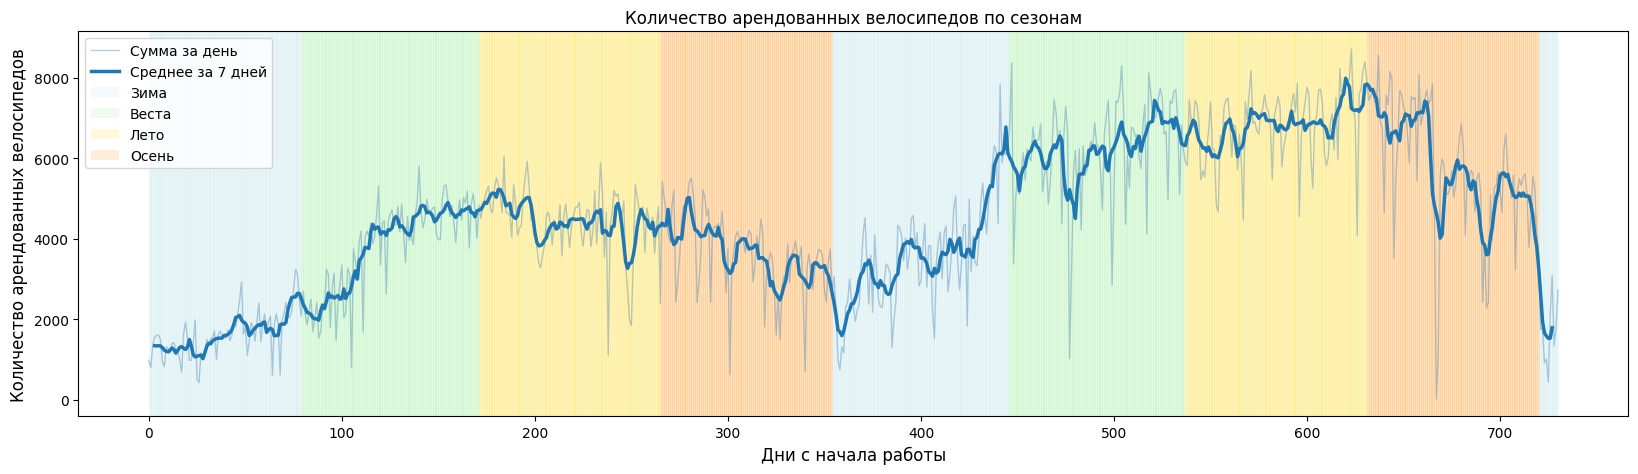

In [51]:
bikes_by_days = pd.DataFrame()
bikes_by_days["cnt"] = raw_bikes["cnt"]
bikes_by_days["season"] = raw_bikes["season"]
bikes_by_days["days_since_launch"] = (
    raw_bikes["dteday"] - raw_bikes["dteday"].min()
).dt.days

bikes_by_days = bikes_by_days.groupby("days_since_launch").agg(
    {"cnt": sum, "season": "first"}
)

bikes_by_days["rolling_mean"] = (
    bikes_by_days["cnt"].rolling(window=7, center=True).mean()
)

f, ax = plt.subplots(figsize=(20, 5))

season_colors = {
    1: ("#B0E0E6", "Зима"),
    2: ("#90EE90", "Веста"),
    3: ("#FFD700", "Лето"),
    4: ("#FF8C00", "Осень"),
}

for i in range(len(bikes_by_days) - 1):
    season = bikes_by_days["season"].iloc[i]
    color, season_name = season_colors[season]
    x_start = bikes_by_days.index[i]
    x_end = bikes_by_days.index[i + 1]
    ax.axvspan(x_start, x_end, alpha=0.15, color=color)

ax.plot(
    bikes_by_days.index,
    bikes_by_days["cnt"],
    label="Сумма за день",
    alpha=0.4,
    linewidth=1,
    color="steelblue",
)

ax.plot(
    bikes_by_days.index,
    bikes_by_days["rolling_mean"],
    label="Среднее за 7 дней",
    linewidth=2.5
)

season_patches = [
    Patch(facecolor=color, alpha=0.15, label=name)
    for color, name in season_colors.values()
]
ax.legend(handles=ax.get_lines() + season_patches, loc="best")

ax.set_xlabel("Дни с начала работы", fontsize=12)
ax.set_ylabel("Количество арендованных велосипедов", fontsize=12)
ax.set_title("Количество арендованных велосипедов по сезонам")

plt.show()


На графике отчетливо видно 2 довольно растянутых "горба" которые можно сопоставить с теплыми сезонами, и падения спроса около зим. В данных есть сезонность

Интересным является то, что во втором году кол-во аренд сильно вырасло, что говорит о повышении спроса со временем

### Анализ аномалий в погодных условиях

Для вычисления нормализованных значений полей windspeed (скорость ветра) и hum (влажность) было произведено делеление на максимальное значение, а не minmax нормализация. Это означает что в случаях когда значения равны 0, это действительно значение полученное с погодного датчика

windspeed == 0: 2180 rows
hum == 0:       22 rows


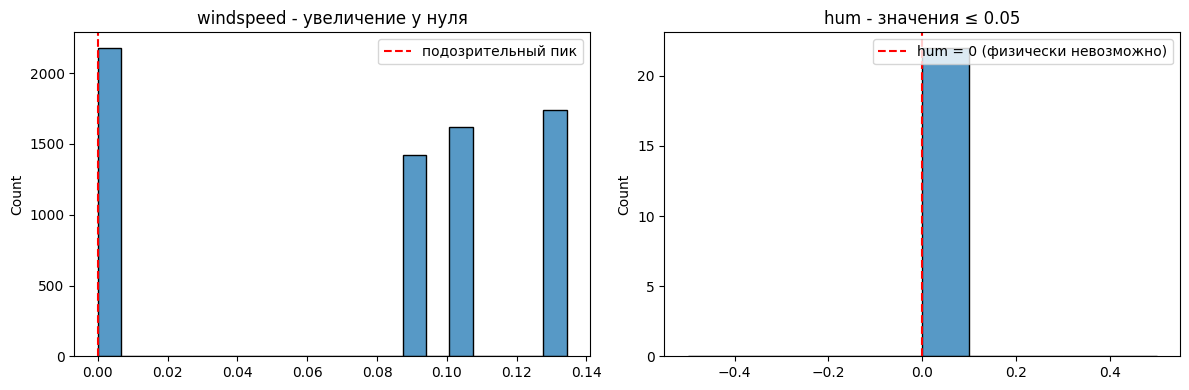

In [52]:
print("windspeed == 0:", (raw_bikes["windspeed"] == 0).sum(), "rows")
print("hum == 0:      ", (raw_bikes["hum"] == 0).sum(), "rows")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title("windspeed - увеличение у нуля")
sns.histplot(list(raw_bikes[raw_bikes["windspeed"] <= 0.15]["windspeed"]),
             bins=20, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", label="подозрительный пик")
axes[0].legend()

axes[1].set_title("hum - значения ≤ 0.05")
sns.histplot(list(raw_bikes[raw_bikes["hum"] <= 0.05]["hum"]),
             bins=10, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", label="hum = 0 (физически невозможно)")
axes[1].legend()

plt.tight_layout()
plt.show()

Как видно, некоторые значения скорости ветра равны 0, это довольно необычный пик с довольно большим количеством значений, но это довольно реальная ситуация для многих мест, так что эти значения можно оставить

Куда больше внимания стоит уделить значениям влажности. Как видно по гистограмме рядом фактически нет значений, и помимо этого, такие значений фактически невозможны на планете. Поэтому принял решение заменить эти значения на средние по тому же дню

In [53]:
overall_hum_median = raw_bikes.loc[raw_bikes["hum"] > 0, "hum"].median()

# если весь день состоит из нулей - среднее ненулевых вернёт NaN, подставляем медиану по датасету
daily_hum_mean = raw_bikes.groupby("dteday")["hum"].transform(
    lambda x: x[x > 0].mean()
).fillna(overall_hum_median)

n_before = (raw_bikes["hum"] == 0).sum()
raw_bikes.loc[raw_bikes["hum"] == 0, "hum"] = daily_hum_mean[raw_bikes["hum"] == 0]
n_after = (raw_bikes["hum"] == 0).sum()

assert raw_bikes["hum"].isna().sum() == 0, "Остались NaN в hum!"
print(f"Заменено значений hum == 0: {n_before - n_after} (осталось нулей: {n_after})")
print(f"Фолбэк-медиана для дней без данных: {overall_hum_median:.4f}")

Заменено значений hum == 0: 22 (осталось нулей: 0)
Фолбэк-медиана для дней без данных: 0.6300


### Анализ количества аренды по сезонам и типу погоды

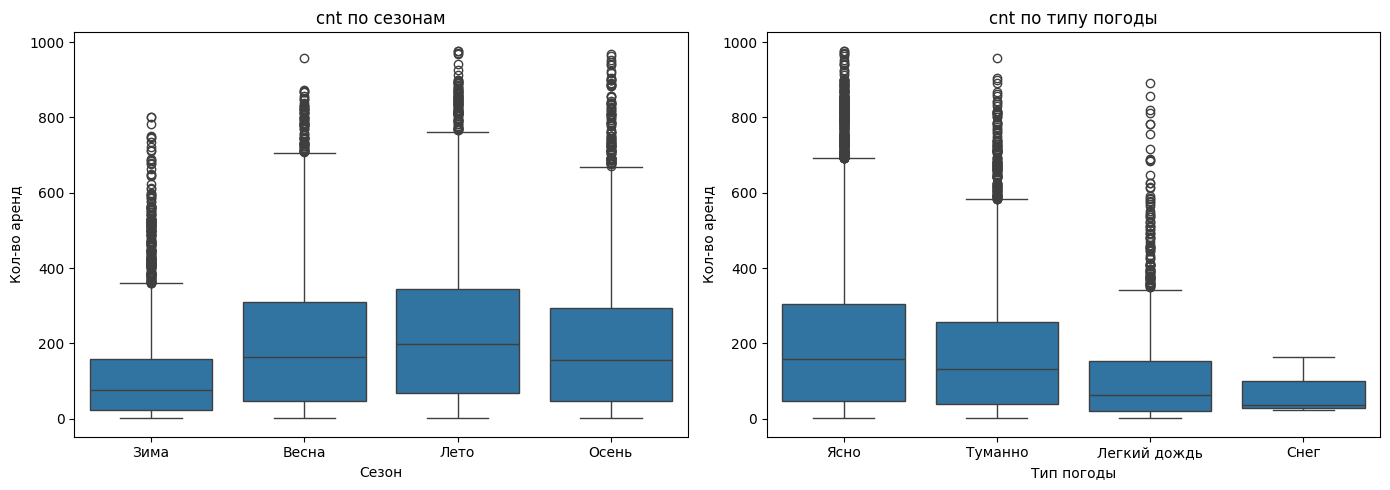

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_labels = {1: "Зима", 2: "Весна", 3: "Лето", 4: "Осень"}
weather_labels = {
    1: "Ясно",
    2: "Туманно",
    3: "Легкий дождь",
    4: "Снег",
}

seasonal = pd.DataFrame()
seasonal["cnt"] = raw_bikes["cnt"]
seasonal["season_label"] = raw_bikes["season"].map(season_labels)
seasonal["weather_label"] = raw_bikes["weathersit"].map(weather_labels)

season_order = list(season_labels.values())
weather_order = list(weather_labels.values())

sns.boxplot(data=seasonal, x="season_label", y="cnt", order=season_order, ax=axes[0])
axes[0].set_title("cnt по сезонам")
axes[0].set_xlabel("Сезон")
axes[0].set_ylabel("Кол-во аренд")

sns.boxplot(data=seasonal, x="weather_label", y="cnt", order=weather_order, ax=axes[1])
axes[1].set_title("cnt по типу погоды")
axes[1].set_xlabel("Тип погоды")
axes[1].set_ylabel("Кол-во аренд")

plt.tight_layout()
plt.show()


Результаты крайне ожидаемые, в теплые сезоны люди арендую чаще чем в холодные, однако в данных прослеживается региональная девиация - зимой люди все-же в довольно большом объеме берут велосипеды на прокат, что может намекать на теплый климат, или отсутствие постоянного снежного покрова

По погоде прослеживается похожая ситуация, в ясную погоду люди берут на прокат велосипеды чаще

Построю heatmap суммы по сезонам и погодам

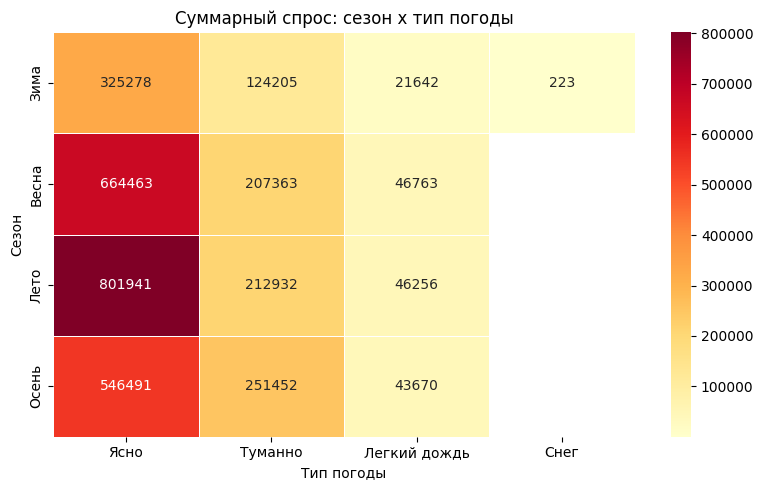

In [55]:
pivot = seasonal.groupby(["season_label", "weather_label"])["cnt"].sum().unstack()
pivot = pivot.reindex(index=season_order, columns=weather_order)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Суммарный спрос: сезон x тип погоды")
ax.set_xlabel("Тип погоды")
ax.set_ylabel("Сезон")
plt.tight_layout()
plt.show()

В целом, рельзультаты совпадают с ожидаемыми, самое большое кол-во аренд приходится на ясную погоду в теплые сезоны. Почти никто не решается бнать велосипеды в дождь или снег

Отсутствие значений осенью, летом и весной в снег ожидаемо - скорее всего в этом регионе снег выпадает только зимой, и достаточно редко

### Корреляция числовых признаков

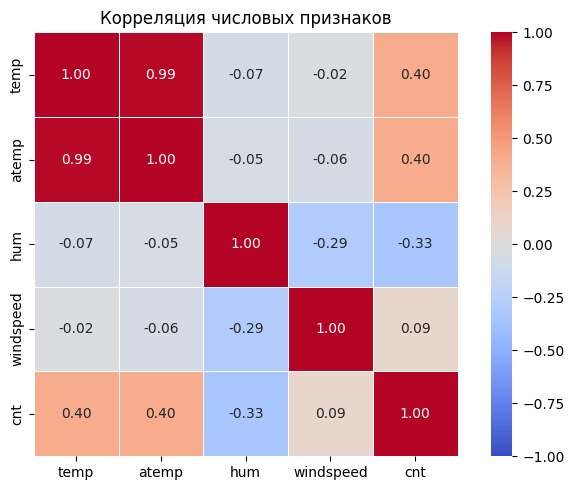

In [56]:
numeric_cols = ["temp", "atemp", "hum", "windspeed", "cnt"]
corr = raw_bikes[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5)
ax.set_title("Корреляция числовых признаков")
plt.tight_layout()
plt.show()

Очевидна сильная корреляция между temp и atemp (подсчитаны из одного исходного значения), также заметна корреляция между температурой и кол-вом аренодованных велосипедов.

Есть также слабамя отрицательная корреляция с hum и windspeed. Это связано с тем, что влажность сильно зависит от погоды, а судя по данным, люди мало берут в аренду велосипеды в условиях плохой погоды

### Автокорреляция целевой переменной

Временной ряд `cnt` - почасовые наблюдения. Анализ автокорреляции позволяет проверить:
- насколько текущий спрос зависит от прошлых значений (лаги 1, 24, 168 - час, день, неделя)
- является ли ряд стационарным (тест ADF)
- отличается ли автокорреляция от шума (тест Льюнга-Бокса)

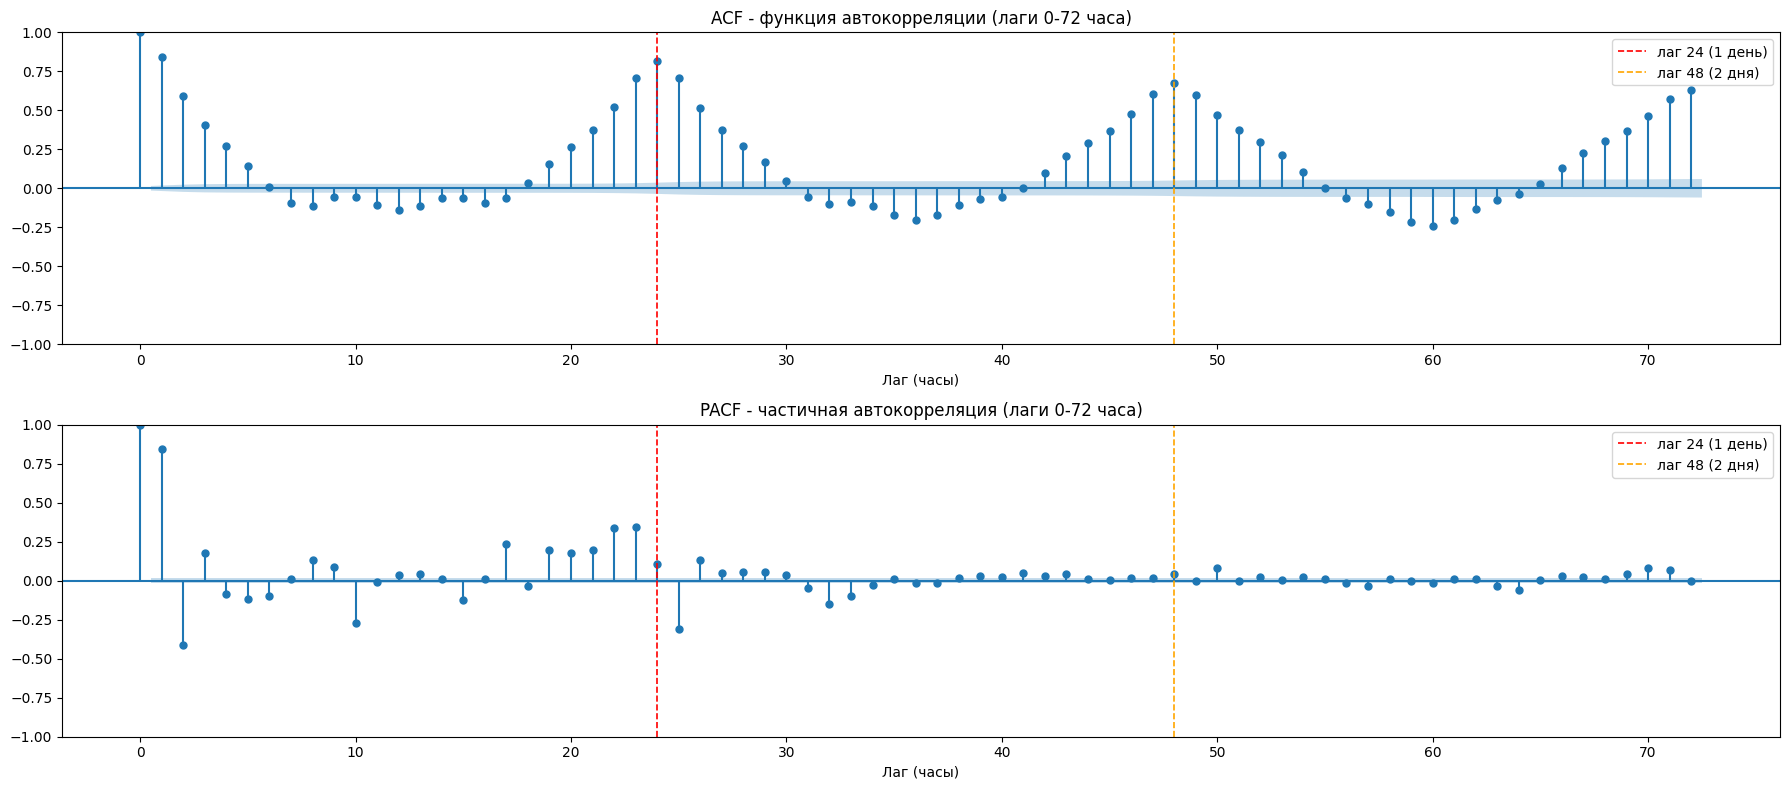

In [57]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

cnt_series = raw_bikes["cnt"].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(18, 8))

plot_acf(cnt_series, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF - функция автокорреляции (лаги 0-72 часа)")
axes[0].set_xlabel("Лаг (часы)")
for lag, color, label in [(24, "red", "лаг 24 (1 день)"), (48, "orange", "лаг 48 (2 дня)")]:
    axes[0].axvline(lag, color=color, linestyle="--", linewidth=1.2, label=label)
axes[0].legend()

plot_pacf(cnt_series, lags=72, method="ywm", ax=axes[1], alpha=0.05)
axes[1].set_title("PACF - частичная автокорреляция (лаги 0-72 часа)")
axes[1].set_xlabel("Лаг (часы)")
for lag, color, label in [(24, "red", "лаг 24 (1 день)"), (48, "orange", "лаг 48 (2 дня)")]:
    axes[1].axvline(lag, color=color, linestyle="--", linewidth=1.2, label=label)
axes[1].legend()

plt.tight_layout()
plt.show()

По графику ACF виден характерный паттерн:
- **Лаг 1**: сильная положительная автокорреляция (~0.85) - соседние часы очень похожи
- **Лаги, кратные 24**: выраженные пики (~0.8 на лаге 24, ~0.65 на лаге 48) - суточная сезонность: одинаковое время суток в разные дни даёт похожий спрос
- **Лаги 8-22**: отрицательные или около нуля - часы ночи и дня находятся в противофазе по уровню спроса

PACF позволяет отделить прямое влияние каждого лага от косвенного: значимый лаг 2 (~-0.5) означает, что после учёта лага 1 соседние значения "перекомпенсируются", что типично для сильного AR(1). Значимый пик на лаге 24 подтверждает прямую суточную зависимость, не объяснимую промежуточными лагами.

#### Тест Дики-Фуллера (ADF, стационарность)

- **H0**: временной ряд имеет единичный корень, то есть является нестационарным
- **H1**: единичного корня нет, ряд стационарен

Уровень значимости: alpha = 0.05. При p-value < alpha H0 отвергается в пользу H1.

In [58]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(cnt_series, autolag="AIC")

print(f"Статистика теста : {adf_result[0]:.4f}")
print(f"p-value          : {adf_result[1]:.6f}")
print(f"Число лагов      : {adf_result[2]}")
print(f"Число наблюдений : {adf_result[3]}")
print("\nКритические значения:")
for key, val in adf_result[4].items():
    print(f"  {key}: {val:.4f}")

conclusion = (
    "стационарен (отвергаем H0, p < 0.05)"
    if adf_result[1] < 0.05
    else "нестационарен (не отвергаем H0, p >= 0.05)"
)
print(f"\n-> Ряд {conclusion}")

Статистика теста : -6.8229
p-value          : 0.000000
Число лагов      : 42
Число наблюдений : 17336

Критические значения:
  1%: -3.4307
  5%: -2.8617
  10%: -2.5669

-> Ряд стационарен (отвергаем H0, p < 0.05)


Тест-статистика (-6.82) значительно меньше критического значения на уровне 1% (-3.43), p-value практически равно нулю. H0 об единичном корне отвергается с запасом - ряд стационарен. Это означает, что его среднее и дисперсия не меняются со временем в долгосрочной перспективе. Видимый визуальный рост числа аренд в 2012 году объясняется детерминированным трендом роста сервиса, а не стохастическим блужданием: суточная и сезонная цикличность удерживают ряд в пределах стационарных колебаний.

#### Тест Льюнга-Бокса

- **H0**: первые m автокорреляций равны нулю - ряд является белым шумом
- **H1**: хотя бы одна из первых m автокорреляций отлична от нуля

Уровень значимости: alpha = 0.05. Проверяем для m = 1, 6, 12, 24, 48.

In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(cnt_series, lags=[1, 6, 12, 24, 48], return_df=True)
lb_result.index.name = "Лаг"
lb_result.columns = ["LB-статистика", "p-value"]

print("=== Тест Льюнга-Бокса ===")
print(lb_result.to_string())
print("\nH0: автокорреляция отсутствует (белый шум)")
print("При p < 0.05 - в ряде есть значимая автокорреляция")

not_rejected = lb_result[lb_result["p-value"] >= 0.05].index.tolist()
if not not_rejected:
    print("\n-> H0 отвергается для всех проверяемых лагов: ряд содержит значимую автокорреляцию")
else:
    print(f"\n-> H0 не отвергается для лагов: {not_rejected}")

=== Тест Льюнга-Бокса ===
     LB-статистика  p-value
Лаг                        
1     12375.195424      0.0
6     23010.735756      0.0
12    24033.376687      0.0
24    53746.200225      0.0
48    97113.789359      0.0

H0: автокорреляция отсутствует (белый шум)
При p < 0.05 - в ряде есть значимая автокорреляция

-> H0 отвергается для всех проверяемых лагов: ряд содержит значимую автокорреляцию


LB-статистики на всех лагах огромны (12 375 на лаге 1, 97 113 на лаге 48), p-value практически равны нулю. H0 отвергается для каждого из m = 1, 6, 12, 24, 48 - ряд `cnt` не является белым шумом ни на одном горизонте. Чем больше лаг, тем выше статистика: это следствие накопления суточной и недельной сезонности. Практический вывод: лаговые признаки (`lag_1`, `lag_24`, `lag_168`) несут значимую предсказательную информацию и должны быть включены в признаковое пространство модели.

# Выводы по EDA

- **Целевая переменная** имеет правосторонний хвост - при обучении стоит применить log1p-преобразование
- **Час дня** - главный предиктор: двумодальный паттерн в рабочие дни (8:00 и 17–18:00), одномодальный в выходные (12–16:00)
- **Температура** умеренно коррелирует с cnt (~0.40); temp и atemp взаимозаменяемы (r=0.99) - в модели достаточно одного
- **Сезонность**: лето > осень > весна > зима; зимний спрос ненулевой - климат DC не исключает аренду
- **Погода**: ясная погода дает максимальный спрос; категории 3 и 4 редки (~3% данных) - обоснование для их объединения при препроцессинге
- **Аномалии**: 22 строки hum=0 заменены средним по дню; windspeed=0 (~12.5%) оставлен как физически корректный

## Сохранение

In [60]:
raw_bikes.to_csv("datasets/eda.csv", index=False)